Noisy value iteration converged after 55 iterations.
c = 0.03
sigma_repr = 0.25
Subjective lower boundary, log10 odds = -0.748
Subjective upper boundary, log10 odds = 0.748
Subjective lower boundary, belief = 0.152
Subjective upper boundary, belief = 0.848


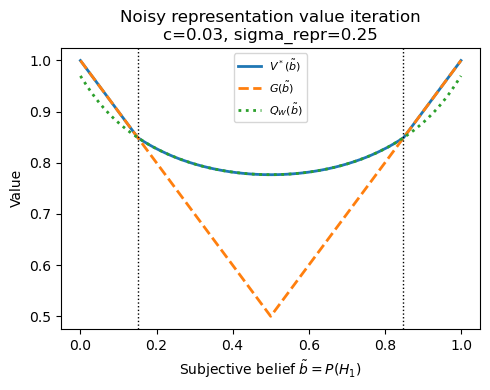

   trial  true_H  time_step  stim_idx  ground_L  subjective_L  ground_b  \
0      0       0          1        12       0.5      0.582609  0.759747   
1      0       0          2        12       1.0      1.308948  0.909091   
2      1       1          1         8       0.1     -0.034238  0.557312   
3      1       1          2         8       0.2      0.156905  0.613137   
4      1       1          3         2      -0.4     -0.435990  0.284747   

   subjective_b  action  
0      0.792738       2  
1      0.953201       1  
2      0.480301       2  
3      0.589352       2  
4      0.268175       2  
action
2    163460
0     23692
1     23467
Name: count, dtype: int64


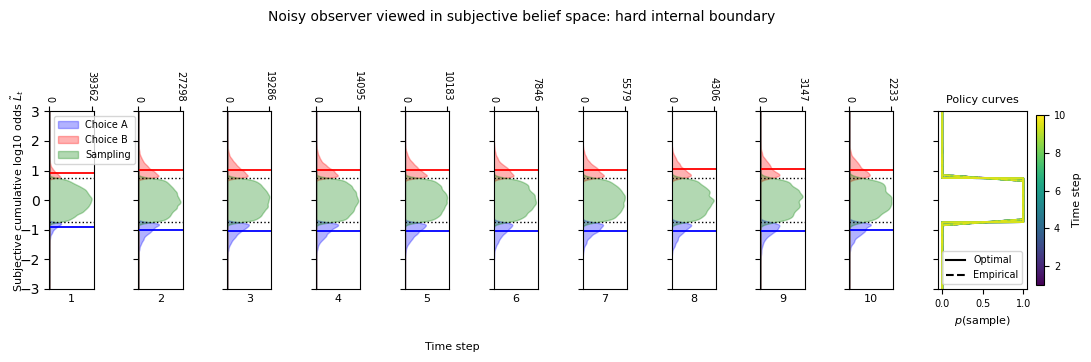

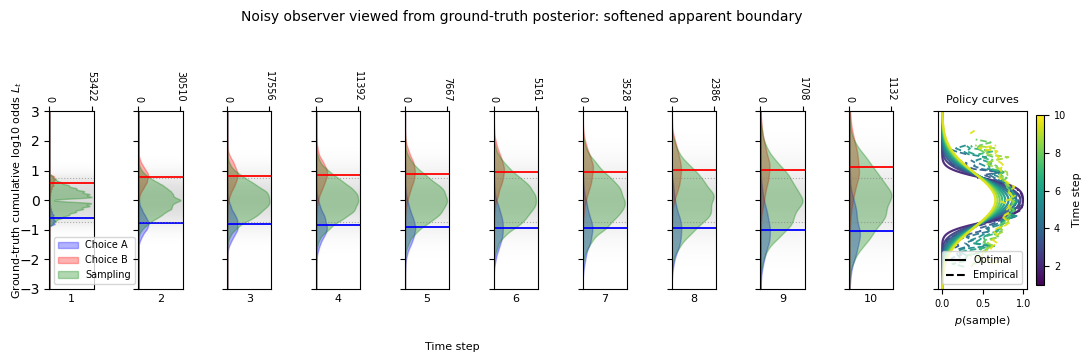

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# Non-ideal observer with Gaussian noise in log10 representation
# Infinite-horizon value iteration in subjective belief space
# Then simulate 5 x 10^4 trials and visualize from:
#   1. subjective/internal belief axis
#   2. ground-truth posterior/evidence axis
# ============================================================

# -----------------------------
# Main parameters
# -----------------------------

c = 0.03
R_correct = 1.0
R_wrong = 0.0

n_trials = 5 * 10**4
max_timestep = 10

# Gaussian representation noise in log10 units.
# This is chosen for visualization of softening over time.
sigma_repr = 0.25

rng = np.random.default_rng(1)

# ============================================================
# 1. Define 16 stimulus types and pA/pB
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)    # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)    # H1 / Target B

# log10 likelihood ratio: log10 P(x|H1) / P(x|H0)
log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Subjective belief grid and helper functions
# ============================================================

N_b = 1001
b_grid = np.linspace(0, 1, N_b)

eps = 1e-12

# Subjective log10 odds grid
L_grid = np.log10(
    np.clip(b_grid, eps, 1 - eps) /
    np.clip(1 - b_grid, eps, 1 - eps)
)

# Avoid infinities at b=0 and b=1 for interpolation
L_min = -4.0
L_max = 4.0
N_L = 2001
L_subj_grid = np.linspace(L_min, L_max, N_L)

b_subj_grid = 1.0 / (1.0 + 10.0 ** (-L_subj_grid))

# Stop value in subjective belief space
G_subj = np.maximum(
    b_subj_grid * R_correct + (1 - b_subj_grid) * R_wrong,
    (1 - b_subj_grid) * R_correct + b_subj_grid * R_wrong
)

def interp_V_L(L_query, L_grid, V):
    """
    Interpolate V over subjective log10 odds.
    Values outside the grid are clipped.
    """
    L_query = np.clip(L_query, L_grid[0], L_grid[-1])
    return np.interp(L_query, L_grid, V)

# ============================================================
# 3. Gaussian-noise value iteration in subjective state
# ============================================================

# Gauss-Hermite quadrature for expectation over Gaussian noise
# If z ~ N(0, 1), E[f(sigma*z)] can be approximated by Hermite nodes.
n_gh = 21
gh_x, gh_w = np.polynomial.hermite.hermgauss(n_gh)
noise_nodes = np.sqrt(2.0) * sigma_repr * gh_x
noise_weights = gh_w / np.sqrt(np.pi)

def compute_noisy_V_star(
    pA,
    pB,
    evidence_log10,
    c,
    L_grid,
    b_grid,
    G,
    sigma_repr,
    tol=1e-9,
    max_iter=5000
):
    """
    Infinite-horizon value iteration for an observer whose internal
    representation of log10 odds is noisy.

    State variable:
        subjective log10 odds L_tilde

    Perfect integration with Gaussian representation noise:
        L_tilde_next = L_tilde + ell_i + noise

    The Bellman wait value integrates over:
        1. possible next stimulus i
        2. Gaussian representational noise
    """

    V = G.copy()

    for iteration in range(max_iter):

        V_old = V.copy()
        Q_wait = np.zeros_like(V)

        for j, L in enumerate(L_grid):

            b = b_grid[j]
            expected_future_value = 0.0

            for i, ell_i in enumerate(evidence_log10):

                # Observer's subjective predictive probability
                q_i = b * pB[i] + (1 - b) * pA[i]

                if q_i <= 0:
                    continue

                # Gaussian-noisy next internal log10 odds
                L_next_nodes = L + ell_i + noise_nodes

                V_next_nodes = interp_V_L(
                    L_next_nodes,
                    L_grid,
                    V_old
                )

                expected_over_noise = np.sum(
                    noise_weights * V_next_nodes
                )

                expected_future_value += q_i * expected_over_noise

            Q_wait[j] = -c + expected_future_value

        V = np.maximum(G, Q_wait)

        diff = np.max(np.abs(V - V_old))

        if diff < tol:
            print(
                f"Noisy value iteration converged after "
                f"{iteration + 1} iterations."
            )
            break

    else:
        print("Warning: noisy value iteration did not converge.")

    return V, Q_wait

V_star_noisy, Q_wait_noisy = compute_noisy_V_star(
    pA=pA,
    pB=pB,
    evidence_log10=target_log_ratios,
    c=c,
    L_grid=L_subj_grid,
    b_grid=b_subj_grid,
    G=G_subj,
    sigma_repr=sigma_repr
)

# ============================================================
# 4. Derive hard optimal boundaries in subjective space
# ============================================================

stop_region = G_subj >= Q_wait_noisy
sample_region = ~stop_region

if np.any(sample_region):
    lower_L_subj = L_subj_grid[sample_region][0]
    upper_L_subj = L_subj_grid[sample_region][-1]
else:
    lower_L_subj = 0.0
    upper_L_subj = 0.0

lower_b_subj = 1.0 / (1.0 + 10.0 ** (-lower_L_subj))
upper_b_subj = 1.0 / (1.0 + 10.0 ** (-upper_L_subj))

print(f"c = {c}")
print(f"sigma_repr = {sigma_repr}")
print(f"Subjective lower boundary, log10 odds = {lower_L_subj:.3f}")
print(f"Subjective upper boundary, log10 odds = {upper_L_subj:.3f}")
print(f"Subjective lower boundary, belief = {lower_b_subj:.3f}")
print(f"Subjective upper boundary, belief = {upper_b_subj:.3f}")

# Hard optimal policy in subjective space
p_sample_optimal_subjective = (
    (L_subj_grid > lower_L_subj) &
    (L_subj_grid < upper_L_subj)
).astype(float)

# ============================================================
# 5. Plot value functions in subjective belief space
# ============================================================

plt.figure(figsize=(5, 4))

plt.plot(
    b_subj_grid,
    V_star_noisy,
    linewidth=2,
    label=r"$V^*(\tilde b)$"
)

plt.plot(
    b_subj_grid,
    G_subj,
    "--",
    linewidth=2,
    label=r"$G(\tilde b)$"
)

plt.plot(
    b_subj_grid,
    Q_wait_noisy,
    ":",
    linewidth=2,
    label=r"$Q_W(\tilde b)$"
)

plt.axvline(lower_b_subj, color="black", linestyle=":", linewidth=1)
plt.axvline(upper_b_subj, color="black", linestyle=":", linewidth=1)

plt.xlabel(r"Subjective belief $\tilde b=P(H_1)$")
plt.ylabel("Value")
plt.title(
    f"Noisy representation value iteration\n"
    f"c={c}, sigma_repr={sigma_repr}"
)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 6. Simulate noisy observer
# ============================================================

sim_rows = []

for trial in range(n_trials):

    true_H = rng.integers(0, 2)  # 0 = H0/A, 1 = H1/B

    # Ground-truth cumulative log10 odds
    L_true = 0.0

    # Observer's subjective/internal log10 odds
    L_subj = 0.0

    for t in range(1, max_timestep + 1):

        # Draw stimulus from true hidden state
        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        ell = target_log_ratios[stim_idx]

        # Ground-truth posterior log10 odds
        L_true += ell

        # Noisy subjective representation with perfect integration
        # This corresponds to:
        #   L_tilde_t = L_tilde_{t-1} + ell_t + epsilon_t
        # where epsilon_t ~ N(0, sigma_repr^2).
        L_subj += ell + rng.normal(0.0, sigma_repr)

        b_true = 1.0 / (1.0 + 10.0 ** (-L_true))
        b_subj = 1.0 / (1.0 + 10.0 ** (-L_subj))

        # Apply hard optimal boundaries in subjective space
        if L_subj <= lower_L_subj:
            action = 0   # choose A / H0
        elif L_subj >= upper_L_subj:
            action = 1   # choose B / H1
        else:
            action = 2   # sample

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "ground_L": L_true,
            "subjective_L": L_subj,
            "ground_b": b_true,
            "subjective_b": b_subj,
            "action": action
        })

        if action in [0, 1]:
            break

df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())

# ============================================================
# 7. Plot helper
#    Two angles:
#       A. subjective log10 belief space
#       B. ground-truth log10 posterior space
# ============================================================

colors_action = {
    0: "blue",
    1: "red",
    2: "green"
}

labels_action = {
    0: "Choice A",
    1: "Choice B",
    2: "Sampling"
}

time_colors = plt.cm.viridis(
    np.linspace(0.1, 0.95, max_timestep)
)

def empirical_policy_by_bins(
    df,
    y_col,
    y_min,
    y_max,
    n_bins=60,
    min_count=10
):
    """
    Empirical p(sample) as a function of y_col, separately for each time step.
    """
    bins = np.linspace(y_min, y_max, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    policy_by_t = {}

    for t in range(1, max_timestep + 1):

        dft = df[df["time_step"] == t]

        y = dft[y_col].to_numpy()
        is_sampling = (dft["action"] == 2).astype(float).to_numpy()

        p_emp = np.full_like(centers, np.nan, dtype=float)

        for k in range(n_bins):
            mask = (y >= bins[k]) & (y < bins[k + 1])
            if mask.sum() >= min_count:
                p_emp[k] = is_sampling[mask].mean()

        policy_by_t[t] = p_emp

    return centers, policy_by_t

def plot_distribution_and_policy(
    df,
    y_col,
    y_label,
    title,
    plot_ground_truth_soft_shadow=False
):
    """
    Left: distributions of cumulative evidence/internal log-odds by action.
    Right: p(sample) policy curves across time.

    If plot_ground_truth_soft_shadow=True:
        add grayscale shadows showing soft sampling probability induced
        by noisy internal representation when viewed from ground-truth space.
    """

    y_min = -3.0
    y_max = 3.0
    y_grid = np.linspace(y_min, y_max, 500)

    fig, axes = plt.subplots(
        1,
        max_timestep + 1,
        figsize=(11.5, 3.4),
        sharey=True,
        gridspec_kw={
            "width_ratios": [1] * max_timestep + [2.4]
        }
    )

    dist_axes = axes[:-1]
    policy_ax = axes[-1]

    # -----------------------------
    # Left distribution panels
    # -----------------------------

    for t in range(1, max_timestep + 1):

        ax = dist_axes[t - 1]
        dft = df[df["time_step"] == t]

        max_density = 0.0

        # Grayscale soft boundary shadow from experimenter's angle
        if plot_ground_truth_soft_shadow:

            # Given cumulative ground-truth L,
            # subjective L_tilde | ground_L approximately:
            #   N(ground_L, t * sigma_repr^2)
            # because perfect integration accumulates independent noise.
            s_t = sigma_repr * np.sqrt(t)

            p_sample_soft = (
                norm.cdf((upper_L_subj - y_grid) / s_t) -
                norm.cdf((lower_L_subj - y_grid) / s_t)
            )

            # Draw as horizontal gray shadow.
            # Darker means higher probability of sampling.
            # Repeated thin bands create an intuitive soft boundary region.
            for k in range(len(y_grid) - 1):
                alpha_k = 0.28 * p_sample_soft[k]
                if alpha_k > 0.005:
                    ax.axhspan(
                        y_grid[k],
                        y_grid[k + 1],
                        color="gray",
                        alpha=alpha_k,
                        linewidth=0
                    )

        for action in [0, 1, 2]:

            action_data = dft[dft["action"] == action]

            if action_data.empty:
                continue

            y = action_data[y_col].to_numpy()

            if len(y) < 3 or np.std(y) == 0:
                continue

            kde = gaussian_kde(y)
            density = kde(y_grid)

            # Scale by count so width roughly reflects frequency
            density_scaled = density * len(y)

            max_density = max(max_density, density_scaled.max())

            ax.fill_betweenx(
                y_grid,
                0,
                density_scaled,
                color=colors_action[action],
                alpha=0.3,
                label=labels_action[action] if t == 1 else None
            )

            if action in [0, 1]:
                mean_y = np.mean(y)
                ax.axhline(
                    mean_y,
                    color=colors_action[action],
                    linewidth=1.3
                )

        # Hard subjective boundaries if plotting subjective space
        if not plot_ground_truth_soft_shadow:
            ax.axhline(
                lower_L_subj,
                color="black",
                linestyle=":",
                linewidth=1
            )
            ax.axhline(
                upper_L_subj,
                color="black",
                linestyle=":",
                linewidth=1
            )

        # Ground-truth angle: show nominal center of internal boundary
        # as gray dotted reference, but the main boundary information is shadow.
        if plot_ground_truth_soft_shadow:
            ax.axhline(
                lower_L_subj,
                color="gray",
                linestyle=":",
                linewidth=0.8,
                alpha=0.6
            )
            ax.axhline(
                upper_L_subj,
                color="gray",
                linestyle=":",
                linewidth=0.8,
                alpha=0.6
            )

        ax.set_ylim(y_min, y_max)

        if max_density > 0:
            ax.set_xlim(0, max_density * 1.05)
            ax.set_xticks([0, int(max_density)])
        else:
            ax.set_xlim(0, 1)
            ax.set_xticks([0, 1])

        ax.xaxis.set_ticks_position("top")
        ax.tick_params(
            axis="x",
            top=True,
            labeltop=True,
            labelbottom=False
        )

        ax.set_xticklabels(
            [str(int(x)) for x in ax.get_xticks()],
            rotation=270,
            fontsize=7
        )

        ax.set_xlabel(str(t), fontsize=8)

    # -----------------------------
    # Right policy curves
    # -----------------------------

    centers, empirical_policy = empirical_policy_by_bins(
        df,
        y_col=y_col,
        y_min=y_min,
        y_max=y_max,
        n_bins=60,
        min_count=10
    )

    for idx, t in enumerate(range(1, max_timestep + 1)):

        color_t = time_colors[idx]

        # Empirical p(sample)
        policy_ax.plot(
            empirical_policy[t],
            centers,
            color=color_t,
            linestyle="--",
            linewidth=1.3,
            alpha=0.95
        )

        if not plot_ground_truth_soft_shadow:

            # Subjective angle:
            # optimal policy is hard and time-independent
            p_sample_optimal = (
                (y_grid > lower_L_subj) &
                (y_grid < upper_L_subj)
            ).astype(float)

            policy_ax.plot(
                p_sample_optimal,
                y_grid,
                color=color_t,
                linewidth=1.4,
                alpha=0.9
            )

        else:

            # Ground-truth angle:
            # optimal subjective hard boundary appears softened.
            s_t = sigma_repr * np.sqrt(t)

            p_sample_soft = (
                norm.cdf((upper_L_subj - y_grid) / s_t) -
                norm.cdf((lower_L_subj - y_grid) / s_t)
            )

            policy_ax.plot(
                p_sample_soft,
                y_grid,
                color=color_t,
                linewidth=1.6,
                alpha=0.95
            )

    policy_ax.set_xlim(-0.05, 1.05)
    policy_ax.set_xticks([0, 0.5, 1.0])
    policy_ax.set_xlabel(r"$p(\mathrm{sample})$", fontsize=8)
    policy_ax.set_title("Policy curves", fontsize=8)
    policy_ax.tick_params(axis="x", labelsize=7)

    # dummy legend
    policy_ax.plot([], [], color="black", linewidth=1.5, label="Optimal")
    policy_ax.plot([], [], color="black", linestyle="--", linewidth=1.5, label="Empirical")
    policy_ax.legend(fontsize=7, loc="lower right")

    sm = plt.cm.ScalarMappable(
        cmap="viridis",
        norm=plt.Normalize(vmin=1, vmax=max_timestep)
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=policy_ax,
        fraction=0.08,
        pad=0.08
    )
    cbar.set_label("Time step", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.text(
        0.44,
        0.03,
        "Time step",
        ha="center",
        fontsize=8
    )

    fig.text(
        0.055,
        0.5,
        y_label,
        va="center",
        rotation="vertical",
        fontsize=8
    )

    fig.suptitle(title, fontsize=10, y=1.03)

    for ax in dist_axes:
        ax.label_outer()

    dist_axes[0].legend(loc="best", fontsize=7)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
    plt.show()

# ============================================================
# 8A. Subjective/internal angle
# Hard optimal boundaries remain hard in subjective space
# ============================================================

plot_distribution_and_policy(
    df=df_sim,
    y_col="subjective_L",
    y_label=r"Subjective cumulative log10 odds $\tilde L_t$",
    title=(
        "Noisy observer viewed in subjective belief space: "
        "hard internal boundary"
    ),
    plot_ground_truth_soft_shadow=False
)

# ============================================================
# 8B. Ground-truth/experimenter angle
# Same subjective hard policy appears soft in ground-truth space
# ============================================================

plot_distribution_and_policy(
    df=df_sim,
    y_col="ground_L",
    y_label=r"Ground-truth cumulative log10 odds $L_t$",
    title=(
        "Noisy observer viewed from ground-truth posterior: "
        "softened apparent boundary"
    ),
    plot_ground_truth_soft_shadow=True
)